## **House Price Prediction**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### ***Load & Inspect The Dataset***

In [2]:
df = pd.read_csv("modified_data.csv")

In [3]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.00,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.00,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.00,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.00,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.00,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09,308166.67,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,204.08
4596,2014-07-09,534333.33,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,365.98
4597,2014-07-09,416904.17,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,138.51
4598,2014-07-10,203400.00,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,97.32


- Shape of the dataset

In [4]:
print("Shape:", df.shape)

Shape: (4600, 18)


- Data types of each column

In [5]:
df.dtypes

date               object
price             float64
bedrooms          float64
bathrooms         float64
sqft_living         int64
sqft_lot            int64
floors            float64
waterfront          int64
view                int64
condition           int64
sqft_above          int64
sqft_basement       int64
yr_built            int64
yr_renovated        int64
street             object
city               object
statezip           object
price_per_sqft    float64
dtype: object

- First 5 rows

In [6]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


- Last 5 rows

In [7]:
df.tail()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
4595,2014-07-09,308166.67,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,204.08
4596,2014-07-09,534333.33,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,365.98
4597,2014-07-09,416904.17,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,138.51
4598,2014-07-10,203400.00,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,97.32
4599,2014-07-10,220600.00,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,148.05


- Summary statistics for numeric columns

In [8]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


- Summary statistics for categorical columns

In [9]:
df.describe(include="object")

,date,street,city,statezip
count,4600,4600,4600,4600
unique,70,4525,44,77
top,2014-06-23,2520 Mulberry Walk NE,Seattle,WA 98103
freq,142,4,1573,148


- Check for missing values

In [10]:
df.isnull().sum()

date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
street            0
city              0
statezip          0
price_per_sqft    0
dtype: int64

- Unique cities in the dataset

In [11]:
df["city"].nunique()

44

- Count of listings per city (top 10)

In [12]:
df["city"].value_counts().head(10)

city
Seattle        1573
Renton          293
Bellevue        286
Redmond         235
Kirkland        187
Issaquah        187
Kent            185
Auburn          176
Sammamish       175
Federal Way     148
Name: count, dtype: int64

#### ***Cleaning & Feature Engineering***

- Drop rows where price is 0 (invalid listings)

In [14]:
df = df[df["price"] > 0].copy()
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.00,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.00,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.00,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.00,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.00,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09,308166.67,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,204.08
4596,2014-07-09,534333.33,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,365.98
4597,2014-07-09,416904.17,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,138.51
4598,2014-07-10,203400.00,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,97.32


- Convert 'date' column to datetime

In [19]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["date"]

0      2014-05-02
1      2014-05-02
2      2014-05-02
3      2014-05-02
4      2014-05-02
          ...    
4595   2014-07-09
4596   2014-07-09
4597   2014-07-09
4598   2014-07-10
4599   2014-07-10
Name: date, Length: 4551, dtype: datetime64[ns]

- Extract year and month sold from date

In [20]:
df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month
df["sale_month"] 
df["sale_year"] 

0       2014
1       2014
2       2014
3       2014
4       2014
        ... 
4595    2014
4596    2014
4597    2014
4598    2014
4599    2014
Name: sale_year, Length: 4551, dtype: int32

- Create 'house_age' feature (age at time of sale)

In [21]:
df["house_age"] = df["sale_year"] - df["yr_built"]
df["house_age"]

0       59
1       93
2       48
3       51
4       38
        ..
4595    60
4596    31
4597     5
4598    40
4599    24
Name: house_age, Length: 4551, dtype: int64

- Create 'was_renovated' flag

In [22]:
df["was_renovated"] = (df["yr_renovated"] > 0).astype(int)
df["was_renovated"]

0       1
1       0
2       0
3       0
4       1
       ..
4595    1
4596    1
4597    0
4598    0
4599    0
Name: was_renovated, Length: 4551, dtype: int64

- Create 'years_since_renovation' (0 if never renovated)

In [24]:
df["years_since_renovation"] = np.where(
    df["was_renovated"] == 1, df["sale_year"] - df["yr_renovated"], 0)
df["years_since_renovation"]

0        9
1        0
2        0
3        0
4       22
        ..
4595    35
4596     5
4597     0
4598     0
4599     0
Name: years_since_renovation, Length: 4551, dtype: int64

- Create total rooms feature

In [26]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["total_rooms"]

0       4.50
1       7.50
2       5.00
3       5.25
4       6.50
        ... 
4595    4.75
4596    5.50
4597    5.50
4598    6.00
4599    5.50
Name: total_rooms, Length: 4551, dtype: float64

- Create ratio of living space to lot size

In [27]:
df["living_to_lot_ratio"] = df["sqft_living"] / df["sqft_lot"]
df["living_to_lot_ratio"]

0       0.169363
1       0.403315
2       0.161547
3       0.249066
4       0.184762
          ...   
4595    0.237421
4596    0.192790
4597    0.429142
4598    0.315234
4599    0.183905
Name: living_to_lot_ratio, Length: 4551, dtype: float64

- Cap extreme outliers in price using the 1st/99th percentile

In [29]:
low, high = df["price"].quantile([0.01, 0.99])
df["price_capped"] = df["price"].clip(low, high)
low, high 
df["price_capped"]

0        313000.00
1       2016000.00
2        342000.00
3        420000.00
4        550000.00
           ...    
4595     308166.67
4596     534333.33
4597     416904.17
4598     203400.00
4599     220600.00
Name: price_capped, Length: 4551, dtype: float64

- One-hot encode the 'city' column (top 10 cities, rest as 'Other')

In [30]:
top_cities = df["city"].value_counts().head(10).index
df["city_grouped"] = np.where(df["city"].isin(top_cities), df["city"], "Other")
city_dummies = pd.get_dummies(df["city_grouped"], prefix="city", drop_first=True)

## ***Visualizations***

- Histogram of house prices

Text(0.5, 0, 'Price')

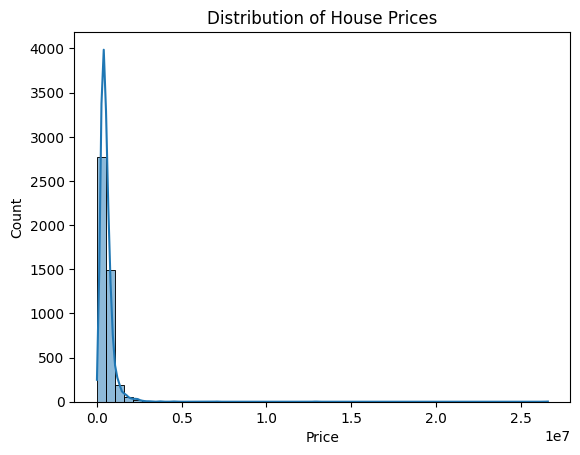

In [35]:
plt.figure()
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")


- Log-transformed price distribution (handles skew)

Text(0.5, 1.0, 'Distribution of Log(Price)')

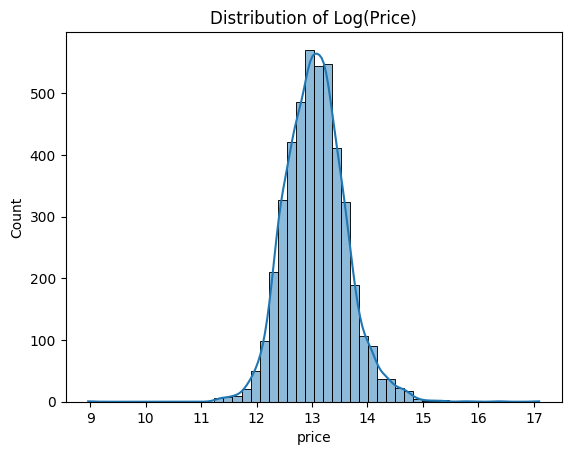

In [36]:
plt.figure()
sns.histplot(np.log1p(df["price"]), bins=50, kde=True)
plt.title("Distribution of Log(Price)")

- Boxplot of price to spot outliers

Text(0.5, 1.0, 'Boxplot of House Prices')

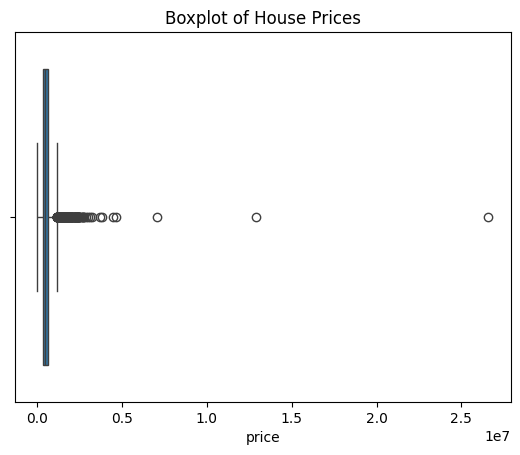

In [37]:
plt.figure()
sns.boxplot(x=df["price"])
plt.title("Boxplot of House Prices")

- Scatter plot: sqft_living vs price

Text(0.5, 1.0, 'Living Area vs Price')

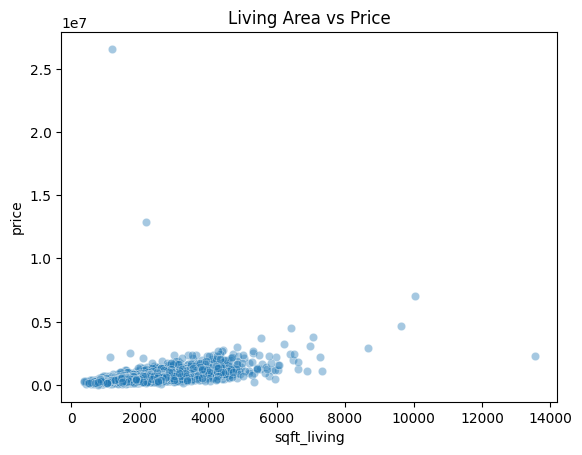

In [38]:
plt.figure()
sns.scatterplot(data=df, x="sqft_living", y="price", alpha=0.4)
plt.title("Living Area vs Price")

- Scatter plot with regression line: sqft_living vs price

Text(0.5, 1.0, 'Living Area vs Price with Trend Line')

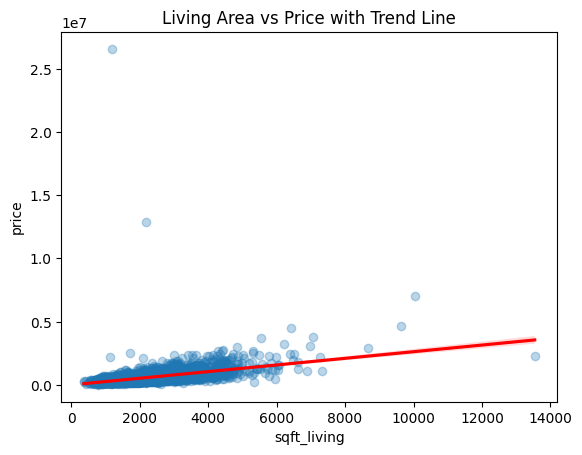

In [39]:
plt.figure()
sns.regplot(data=df, x="sqft_living", y="price", scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
plt.title("Living Area vs Price with Trend Line")

- Bar chart: average price by number of bedrooms

Text(0, 0.5, 'Average Price')

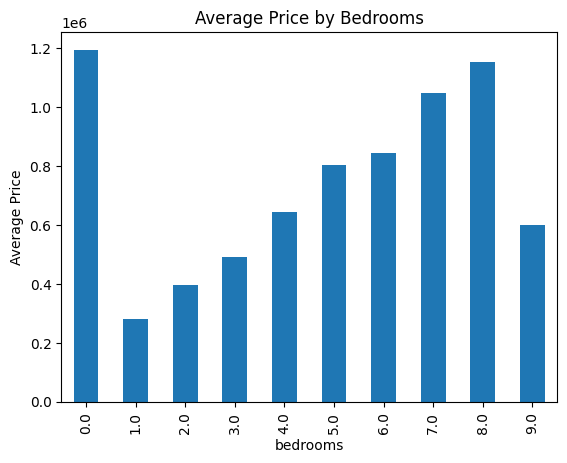

In [40]:
plt.figure()
df.groupby("bedrooms")["price"].mean().plot(kind="bar")
plt.title("Average Price by Bedrooms")
plt.ylabel("Average Price")

- Bar chart: average price by number of bathrooms

Text(0.5, 1.0, 'Average Price by Bathrooms')

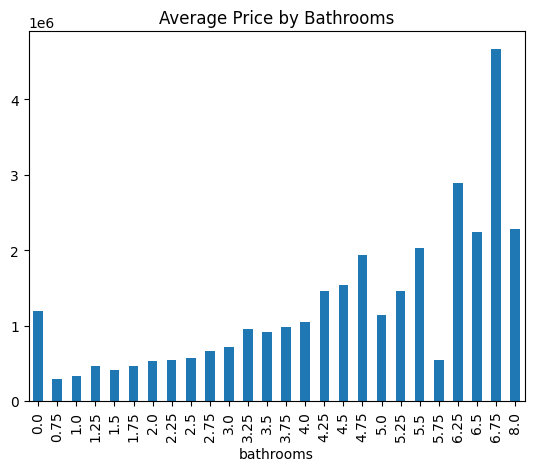

In [41]:
plt.figure()
df.groupby("bathrooms")["price"].mean().plot(kind="bar")
plt.title("Average Price by Bathrooms")

- Boxplot: price distribution across floor counts

Text(0.5, 1.0, 'Price Distribution by Floor Count')

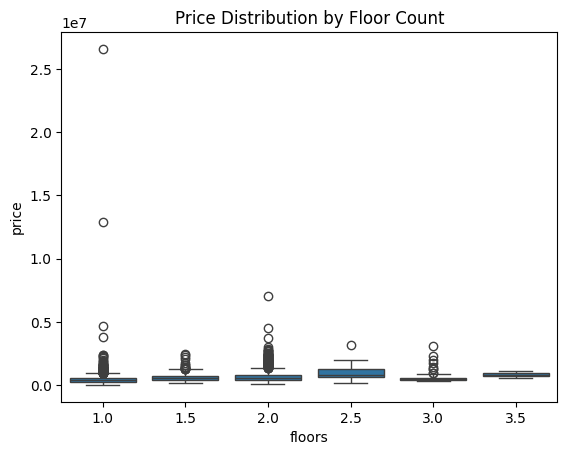

In [42]:
plt.figure()
sns.boxplot(data=df, x="floors", y="price")
plt.title("Price Distribution by Floor Count")

- Violin plot: price by waterfront property

Text(0.5, 1.0, 'Price Distribution: Waterfront vs Non-Waterfront')

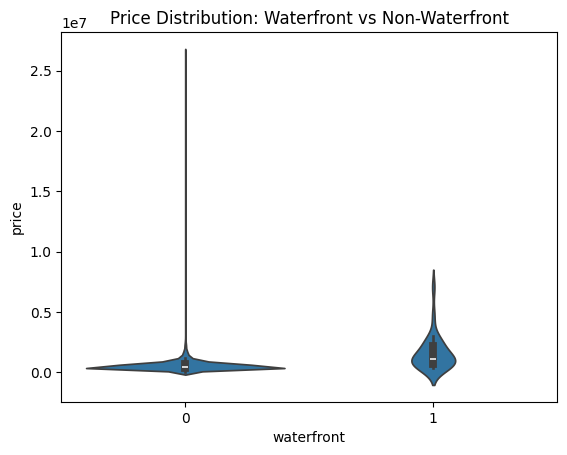

In [43]:
plt.figure()
sns.violinplot(data=df, x="waterfront", y="price")
plt.title("Price Distribution: Waterfront vs Non-Waterfront")

- Boxplot: price by condition rating

Text(0.5, 1.0, 'Price by Condition Rating')

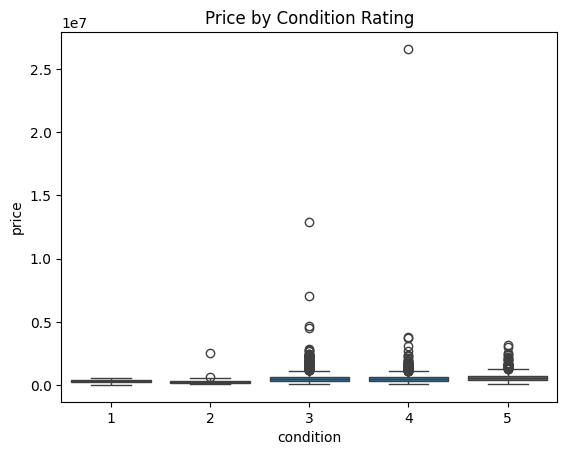

In [44]:
plt.figure()
sns.boxplot(data=df, x="condition", y="price")
plt.title("Price by Condition Rating")

- Boxplot: price by view rating


Text(0.5, 1.0, 'Price by View Rating')

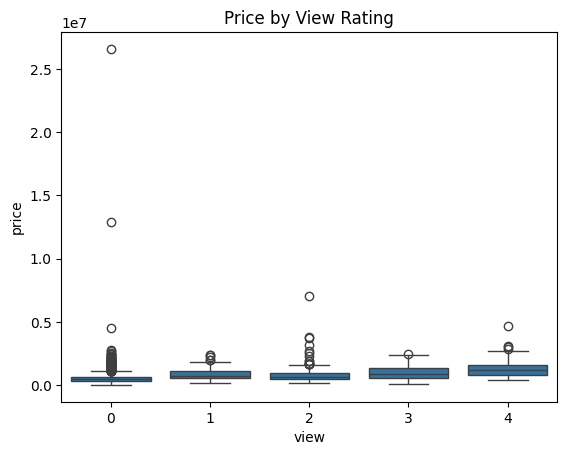

In [45]:
plt.figure()
sns.boxplot(data=df, x="view", y="price")
plt.title("Price by View Rating")
